Import pickle to load saved machine learning models.


In [24]:
import pickle


Open and load the saved machine learning model.


In [25]:
ml_model_file = open("ml_model.pkl", "rb")
ml_model = pickle.load(ml_model_file)
ml_model_file.close()


Import pandas to read and handle the dataset.


In [26]:
import pandas as pd


Read the heart disease dataset.


In [27]:
df = pd.read_csv("heart_dataset.csv")


Select all feature columns up to `thallium_heart_rate`.


In [28]:
dataset_features = df.loc[:, :"thallium_heart_rate"]


Store the feature names in a list.


In [29]:
feature_names = dataset_features.columns.to_list()


Get all decision trees from the random forest model.


In [30]:
decision_trees = ml_model.estimators_


Print the number of decision trees.


In [31]:
print(len(decision_trees))


100


Select the first decision tree for visualization.


In [32]:
decision_tree = decision_trees[0]


Import `plot_tree` to visualize decision trees.


In [33]:
from sklearn.tree import plot_tree


Plot the full decision tree.


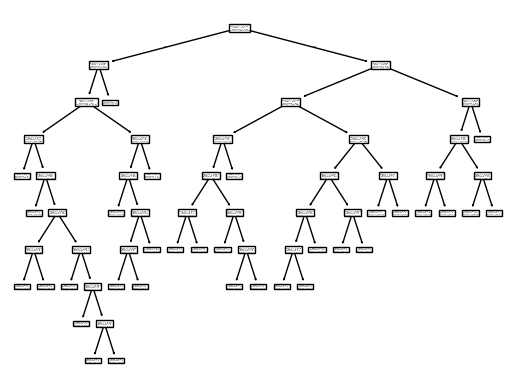

In [34]:
_ = plot_tree(decision_tree)


Plot only the first two levels of the decision tree with feature names.


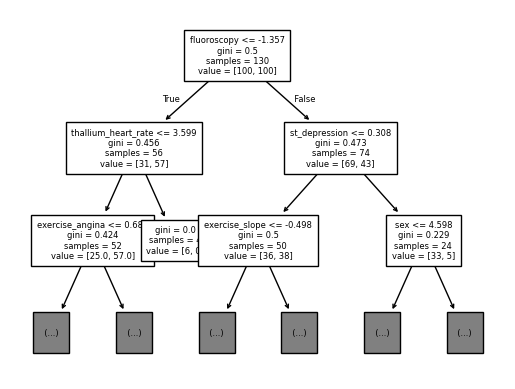

In [35]:
_ = plot_tree(
    decision_tree,
    max_depth=2,
    feature_names=feature_names,
    fontsize=6
)


Open and load the saved deep learning model.


In [36]:
import torch.nn as nn

class HeartDLModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(13, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

dl_model_file = open("dl_model.pkl", "rb")
dl_model = pickle.load(dl_model_file)
dl_model_file.close()

Convert the dataset features into a NumPy array.


In [37]:
dataset_features = dataset_features.to_numpy()


Select the first sample from the dataset.


In [38]:
one_sample_features = dataset_features[0]


Import PyTorch to convert NumPy arrays into tensors.


In [39]:
import torch


Wrap the deep learning model so SHAP can call it using NumPy input.


In [40]:
dl_model_wrapped = lambda features: dl_model(
    torch.Tensor(features)
).detach().numpy()


Import `tqdm` and SHAP for model explanation.


In [41]:
import tqdm.auto
import shap


Create a SHAP KernelExplainer using the first 100 samples as background data.


In [42]:
shap_explainer = shap.KernelExplainer(
    dl_model_wrapped,
    dataset_features[:100]
)


Get the expected/base prediction value from SHAP.


In [43]:
shap_expected_value = shap_explainer.expected_value


Calculate SHAP values for one sample.


In [44]:
one_sample_shap_values = shap_explainer.shap_values(one_sample_features)


Print the SHAP values for the selected sample.


In [45]:
print(one_sample_shap_values)


[[ 0.00211245]
 [-0.00125706]
 [-0.01281606]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.0007592 ]
 [ 0.        ]
 [ 0.00113645]
 [-0.00144957]
 [-0.00171423]
 [ 0.00217822]
 [-0.00039891]]


Import Matplotlib to display SHAP plots.


In [46]:
import matplotlib.pyplot as plt


Create a force plot to explain the prediction for one sample.


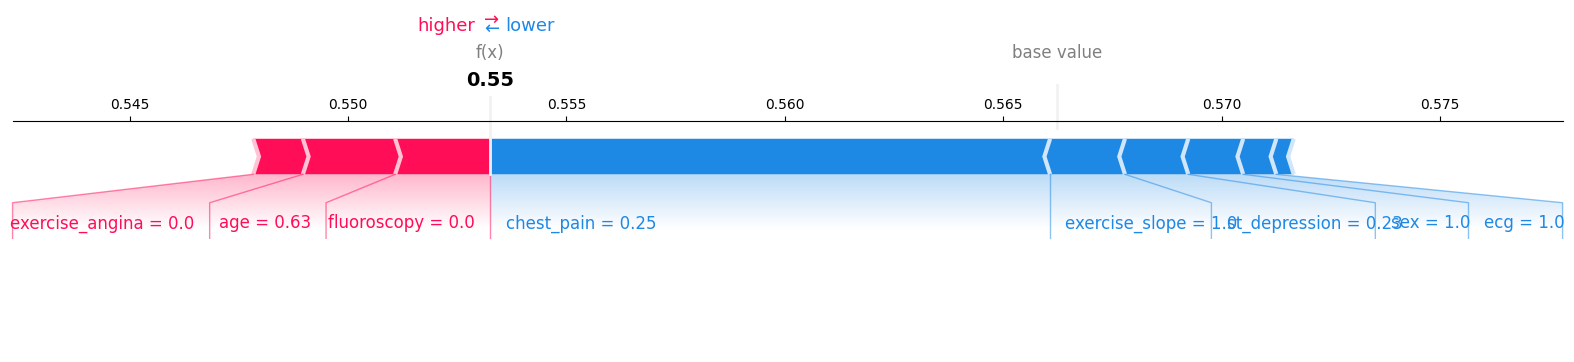

In [47]:
single_shap_values = one_sample_shap_values.flatten()

shap.force_plot(
    shap_expected_value[0],
    single_shap_values,
    one_sample_features,
    feature_names=feature_names,
    matplotlib=True,
    show=True
)

Select the first 10 samples for a summary explanation.


In [48]:
multiple_samples_features = dataset_features[:10]


Calculate SHAP values for the first 10 samples.


In [49]:
multiple_samples_shap_values = shap_explainer.shap_values(
    multiple_samples_features
)


  0%|          | 0/10 [00:00<?, ?it/s]

Create a summary plot showing feature importance across multiple samples.


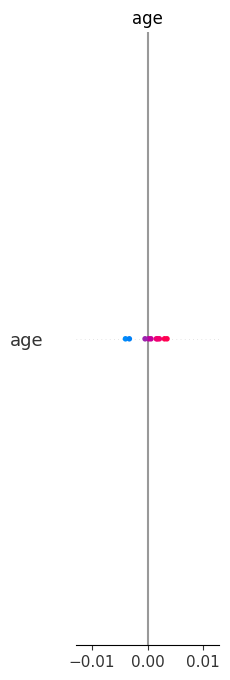

In [50]:
shap.summary_plot(
    multiple_samples_shap_values,
    multiple_samples_features,
    feature_names=feature_names
)
